In [1]:
!source CalceVENV/bin/activate

In [2]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#                              Import libraries
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from stable_baselines3 import SAC
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
import warnings
warnings.filterwarnings('ignore')
 
from BatteryEnvironment import BatteryEnv

## Пункт 1 reward в рублях. 
Вместо абстрактного * 2.0 считаем реальные деньги. Меняем одну формулу в step().

``` python
        # 3. Экономическая логика (Reward)
        # Сколько бы мы заплатили без батарей
        cost_without_battery = max(0.0, load - pv) * price
        # Сколько мы платим с учетом работы батарей
        cost_with_battery = max(0.0, load - pv + total_applied_power) * price
        # Экономия - это то, что мы "выиграли"
        savings = cost_without_battery - cost_with_battery
        # Итоговый реворд: Выгода минус штраф за износ
        reward = savings - total_wear_cost
```

## Пункт 2. 
В своей среде BatteryEnv мы добавляем второй профиль и вторую нагрузку. Конкретно: берём cell_id="CS2_36" вместо CS2_35 — это и есть "вторая батарея/здание". Запускаем обучение SAC заново на CS2_36 и сравниваем результаты. Это доказывает универсальность алгоритма.

In [4]:
class RewardLoggerCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=500, verbose=0):
        super().__init__(verbose)
        self.eval_env     = eval_env
        self.eval_freq    = eval_freq
        self.reward_log   = []   # средняя награда на eval
        self.steps_log    = []   # номер шага

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            rewards = []
            for _ in range(5):  # 5 эпизодов для оценки
                obs, _ = self.eval_env.reset()
                done, total = False, 0.0
                while not done:
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, r, terminated, truncated, _ = self.eval_env.step(action)
                    total += r
                    done = terminated or truncated
                rewards.append(total)
            mean_r = np.mean(rewards)
            self.reward_log.append(mean_r)
            self.steps_log.append(self.n_calls)
            if self.verbose:
                print(f"  Шаг {self.n_calls:6d} | Средняя награда: {mean_r:.2f}")
        return True

In [5]:

def run_random(env, n_episodes=10):
    """Случайный агент."""
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action = env.action_space.sample()
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)


def rule_based_policy(obs):
    hour = round(float(obs[5]))
    if hour <= 6:
        return np.array([1.0], dtype=np.float32)   # заряд ночью
    if 18 <= hour <= 22:
        return np.array([-1.0], dtype=np.float32)  # разряд в пик
    return np.array([0.0], dtype=np.float32)        # пауза


def run_rule_based(env, n_episodes=10):
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action = rule_based_policy(obs)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)

def run_sac(model, env, n_episodes=10):
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)

def run_ppo(model, env, n_episodes=10):
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)

**ПОМАРКА: Все что выше, то это для любого запуска (база). Все что ниже, то это только для запуска одной батареи

In [8]:
def train_sac(total_timesteps=30_000):
    print("=" * 60)
    print("  Этап 3: Обучение SAC-агента")
    print("=" * 60)

    # Среда для обучения и оценки
    train_env = Monitor(BatteryEnv(cell_id="CS2_35"))
    eval_env  = BatteryEnv(cell_id="CS2_35")

    # SAC с настройками под нашу задачу
    model = SAC(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4, #!!!!!
        buffer_size=50_000, #!!!!!
        learning_starts=500,
        batch_size=256, #!!!!
        tau=0.005,
        gamma=0.999,
        ent_coef="auto",          # автоматическая настройка энтропии
        policy_kwargs=dict(net_arch=[256, 256]),  # 2 скрытых слоя
        verbose=0,
    )

    # Callback для логирования
    callback = RewardLoggerCallback(eval_env, eval_freq=500, verbose=1)

    print(f"\nОбучение {total_timesteps:,} шагов...")
    model.learn(total_timesteps=total_timesteps, callback=callback)
    model.save("sac_battery_model")
    print("\nМодель сохранена: sac_battery_model.zip")

    return model, callback

In [ ]:
def train_ppo(total_timesteps=30_000):
    print("=" * 60)
    print("  Этап 3: Обучение PPO-агента")
    print("=" * 60)

    train_env = Monitor(BatteryEnv(cell_id="CS2_35"))
    eval_env  = BatteryEnv(cell_id="CS2_35")

    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4,
        n_steps=2048,        # шагов до обновления политики
        batch_size=64,
        n_epochs=10,
        gamma=0.999,
        gae_lambda=0.95,     # GAE для оценки преимущества
        clip_range=0.2,      # PPO clip
        ent_coef=0.01,       # энтропийный бонус
        policy_kwargs=dict(net_arch=[256, 256]),
        verbose=0,
    )

    callback = RewardLoggerCallback(eval_env, eval_freq=500, verbose=1)

    print(f"\nОбучение {total_timesteps:,} шагов...")
    model.learn(total_timesteps=total_timesteps, callback=callback)
    model.save("ppo_battery_model")
    print("\nМодель сохранена: ppo_battery_model.zip")

    return model, callback

In [7]:
def run_episode_detailed(env, policy_fn):
    obs, _ = env.reset()
    history = {k: [] for k in [
        'hour', 'soc', 'soh', 'price', 'reward',
        'grid_flow', 'action',
        'cost_rub', 'wear_rub', 'bonus_rub'  # новые ключи под новый info
    ]}
    done = False

    while not done:
        action = policy_fn(obs)
        next_obs, r, terminated, truncated, info = env.step(action)

        history['hour'].append(int(obs[5]))
        history['soc'].append(float(obs[0]))
        history['soh'].append(float(obs[1]))
        history['price'].append(float(obs[4]))
        history['reward'].append(r)
        history['grid_flow'].append(info.get('grid_flow', 0.0))
        history['action'].append(float(action[0]))
        history['cost_rub'].append(info.get('cost_rub', 0.0))
        history['wear_rub'].append(info.get('wear_rub', 0.0))
        history['bonus_rub'].append(info.get('bonus_rub', 0.0))

        obs = next_obs
        done = terminated or truncated

    history['total_reward']    = sum(history['reward'])
    history['total_cost_rub']  = sum(history['cost_rub'])
    history['total_wear_rub']  = sum(history['wear_rub'])
    history['total_bonus_rub'] = sum(history['bonus_rub'])
    return history

In [8]:
def compare_and_plot(model_sac, cb_sac, model_ppo, cb_ppo):
    env = BatteryEnv(cell_id="CS2_35")

    print("\nОценка стратегий (10 эпизодов каждая)...")
    r_random = run_random(env)
    r_rule   = run_rule_based(env)
    r_sac    = run_sac(model_sac, env)
    r_ppo    = run_ppo(model_ppo, env)

    print(f"  Random:     {r_random:.2f}")
    print(f"  Rule-Based: {r_rule:.2f}")
    print(f"  PPO:        {r_ppo:.2f}")
    print(f"  SAC:        {r_sac:.2f}")

    # Детальные прогоны
    h_random = run_episode_detailed(env, lambda obs: env.action_space.sample())
    h_rule   = run_episode_detailed(env, rule_based_policy)
    h_ppo    = run_episode_detailed(env, lambda obs: model_ppo.predict(obs, deterministic=True)[0])
    h_sac    = run_episode_detailed(env, lambda obs: model_sac.predict(obs, deterministic=True)[0])

    # Таблица декомпозиции для научника
    print("\nДЕКОМПОЗИЦИЯ REWARD (в рублях)")
    print("=" * 65)
    print(f"{'Стратегия':<14} {'Reward':>10} {'Затраты₽':>10} {'Износ₽':>10} {'Бонус₽':>10}")
    print("-" * 65)
    for name, h in [('Random', h_random), ('Rule-Based', h_rule),
                    ('PPO', h_ppo), ('SAC', h_sac)]:
        print(f"{name:<14} {h['total_reward']:>10.2f} "
              f"{h['total_cost_rub']:>10.2f} "
              f"{h['total_wear_rub']:>10.4f} "
              f"{h['total_bonus_rub']:>10.2f}")
    print("=" * 65)
    print("Reward = -Затраты₽ - Износ₽ + Бонус₽")

    # Графики — остаются те же что были
    colors = {'random': '#AAAAAA', 'rule': '#E24B4A', 'ppo': '#EF9F27', 'sac': '#1D9E75'}

    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # График 1: Кривые обучения SAC и PPO
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(cb_sac.steps_log, cb_sac.reward_log,
             color=colors['sac'], lw=2.5, marker='o', markersize=3, label='SAC')
    ax1.plot(cb_ppo.steps_log, cb_ppo.reward_log,
             color=colors['ppo'], lw=2.5, marker='s', markersize=3, label='PPO')
    ax1.axhline(r_random, color=colors['random'], lw=1.5, ls='--', label=f'Random ({r_random:.1f})')
    ax1.axhline(r_rule,   color=colors['rule'],   lw=1.5, ls='--', label=f'Rule-Based ({r_rule:.1f})')
    ax1.set_title('Кривые обучения SAC vs PPO', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Шаги обучения')
    ax1.set_ylabel('Суммарная награда (₽)')
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3)

    # График 2: Bar chart
    ax2 = fig.add_subplot(gs[1, 0])
    strategies = ['Random', 'Rule-Based', 'PPO', 'SAC']
    values     = [r_random, r_rule, r_ppo, r_sac]
    bar_colors = [colors['random'], colors['rule'], colors['ppo'], colors['sac']]
    bars = ax2.bar(strategies, values, color=bar_colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, values):
        ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 1.5
        ax2.text(bar.get_x() + bar.get_width()/2, ypos,
                 f'{val:.1f}₽', ha='center', fontsize=10, fontweight='bold')
    ax2.set_title('Итоговая награда за сутки (₽)\n(ближе к 0 = лучше)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Reward (₽)')
    ax2.grid(axis='y', alpha=0.3)

    # График 3: SOC в течение суток
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(h_random['hour'], h_random['soc'], color=colors['random'], lw=1.5, ls=':', label='Random')
    ax3.plot(h_rule['hour'],   h_rule['soc'],   color=colors['rule'],   lw=2,   ls='--', label='Rule-Based')
    ax3.plot(h_ppo['hour'],    h_ppo['soc'],    color=colors['ppo'],    lw=2,   ls='-.', label='PPO')
    ax3.plot(h_sac['hour'],    h_sac['soc'],    color=colors['sac'],    lw=2.5, label='SAC')
    ax3.set_title('SOC в течение суток', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Час суток')
    ax3.set_ylabel('SOC')
    ax3.set_ylim(-0.05, 1.1)
    ax3.legend(fontsize=10)
    ax3.grid(alpha=0.3)

    # График 4: Действия SAC vs цена
    ax4 = fig.add_subplot(gs[2, 0])
    ax4_twin = ax4.twinx()
    ax4.bar(h_sac['hour'], h_sac['action'],
            color=[colors['sac'] if a >= 0 else colors['rule'] for a in h_sac['action']],
            alpha=0.7, label='Действие SAC')
    ax4_twin.step(h_sac['hour'], h_sac['price'],
                  color='black', lw=1.5, ls='--', where='post', label='Тариф')
    ax4.set_title('Действия SAC vs Тариф', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Час суток')
    ax4.set_ylabel('Действие (+ заряд / − разряд)', color=colors['sac'])
    ax4_twin.set_ylabel('Тариф (₽/кВт·ч)', color='black')
    ax4.axhline(0, color='gray', lw=0.8)
    ax4.grid(alpha=0.3)

    # График 5: Декомпозиция затрат
    ax5 = fig.add_subplot(gs[2, 1])
    x = np.arange(4)
    width = 0.25
    cost_vals = [h_random['total_cost_rub'], h_rule['total_cost_rub'],
                 h_ppo['total_cost_rub'],    h_sac['total_cost_rub']]
    wear_vals = [h_random['total_wear_rub'], h_rule['total_wear_rub'],
                 h_ppo['total_wear_rub'],    h_sac['total_wear_rub']]
    bonus_vals= [h_random['total_bonus_rub'],h_rule['total_bonus_rub'],
                 h_ppo['total_bonus_rub'],   h_sac['total_bonus_rub']]
    ax5.bar(x - width, cost_vals,  width, label='Затраты₽',  color='#E24B4A', alpha=0.8)
    ax5.bar(x,         wear_vals,  width, label='Износ₽',    color='#EF9F27', alpha=0.8)
    ax5.bar(x + width, bonus_vals, width, label='Бонус₽',    color='#1D9E75', alpha=0.8)
    ax5.set_xticks(x)
    ax5.set_xticklabels(strategies)
    ax5.set_title('Декомпозиция Reward по компонентам (₽)', fontsize=12, fontweight='bold')
    ax5.set_ylabel('₽')
    ax5.legend(fontsize=9)
    ax5.grid(axis='y', alpha=0.3)

    plt.suptitle('SAC vs PPO — BatteryEnv (CALCE CS2) — Reward в рублях',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.savefig('sac_ppo_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nГрафик сохранён: sac_ppo_results.png")

    return {'random': r_random, 'rule_based': r_rule, 'ppo': r_ppo, 'sac': r_sac}

In [ ]:
model_sac, cb_sac = train_sac(total_timesteps=30_000)

  Этап 3: Обучение SAC-агента

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда: -104.00
  Шаг   1000 | Средняя награда: -97.81
  Шаг   1500 | Средняя награда: -91.86
  Шаг   2000 | Средняя награда: -83.89
  Шаг   2500 | Средняя награда: -86.45
  Шаг   3000 | Средняя награда: -80.89
  Шаг   3500 | Средняя награда: -83.15
  Шаг   4000 | Средняя награда: -79.89
  Шаг   4500 | Средняя награда: -80.58
  Шаг   5000 | Средняя награда: -79.18
  Шаг   5500 | Средняя награда: -79.49
  Шаг   6000 | Средняя награда: -79.85
  Шаг   6500 | Средняя награда: -79.48
  Шаг   7000 | Средняя награда: -79.46
  Шаг   7500 | Средняя награда: -79.50
  Шаг   8000 | Средняя награда: -79.69
  Шаг   8500 | Средняя награда: -79.51
  Шаг   9000 | Средняя награда: -79.44
  Шаг   9500 | Средняя награда: -79.73
  Шаг  10000 | Средняя награда: -79.37
  Шаг  10500 | Средняя награда: -79.65
  Шаг  11000 | Средняя награда: -79.48
  Шаг  11500 | Средняя награда: -79.28
  Шаг  12000 | Средняя награда: -79.34
  Шаг  

In [ ]:
model_ppo, cb_ppo = train_ppo(total_timesteps=30_000)

  Этап 3: Обучение PPO-агента

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда: -104.31
  Шаг   1000 | Средняя награда: -104.29
  Шаг   1500 | Средняя награда: -104.25
  Шаг   2000 | Средняя награда: -104.28
  Шаг   2500 | Средняя награда: -88.26
  Шаг   3000 | Средняя награда: -87.55
  Шаг   3500 | Средняя награда: -88.24
  Шаг   4000 | Средняя награда: -88.20
  Шаг   4500 | Средняя награда: -104.28
  Шаг   5000 | Средняя награда: -104.33
  Шаг   5500 | Средняя награда: -104.33
  Шаг   6000 | Средняя награда: -104.21
  Шаг   6500 | Средняя награда: -85.99
  Шаг   7000 | Средняя награда: -85.84
  Шаг   7500 | Средняя награда: -86.03
  Шаг   8000 | Средняя награда: -86.04
  Шаг   8500 | Средняя награда: -95.29
  Шаг   9000 | Средняя награда: -93.52
  Шаг   9500 | Средняя награда: -94.32
  Шаг  10000 | Средняя награда: -93.76
  Шаг  10500 | Средняя награда: -102.12
  Шаг  11000 | Средняя награда: -101.86
  Шаг  11500 | Средняя награда: -102.20
  Шаг  12000 | Средняя награда: -101


Оценка стратегий (10 эпизодов каждая)...
  Random:     -107.61
  Rule-Based: -96.28
  PPO:        -96.27
  SAC:        -79.45

ДЕКОМПОЗИЦИЯ REWARD (в рублях)
Стратегия          Reward   Затраты₽     Износ₽     Бонус₽
-----------------------------------------------------------------
Random            -114.31     114.28     0.0302       0.00
Rule-Based         -96.10      96.10     0.0073       0.00
PPO                -95.55      95.54     0.0065       0.00
SAC                -79.12      79.09     0.0234       0.00
Reward = -Затраты₽ - Износ₽ + Бонус₽


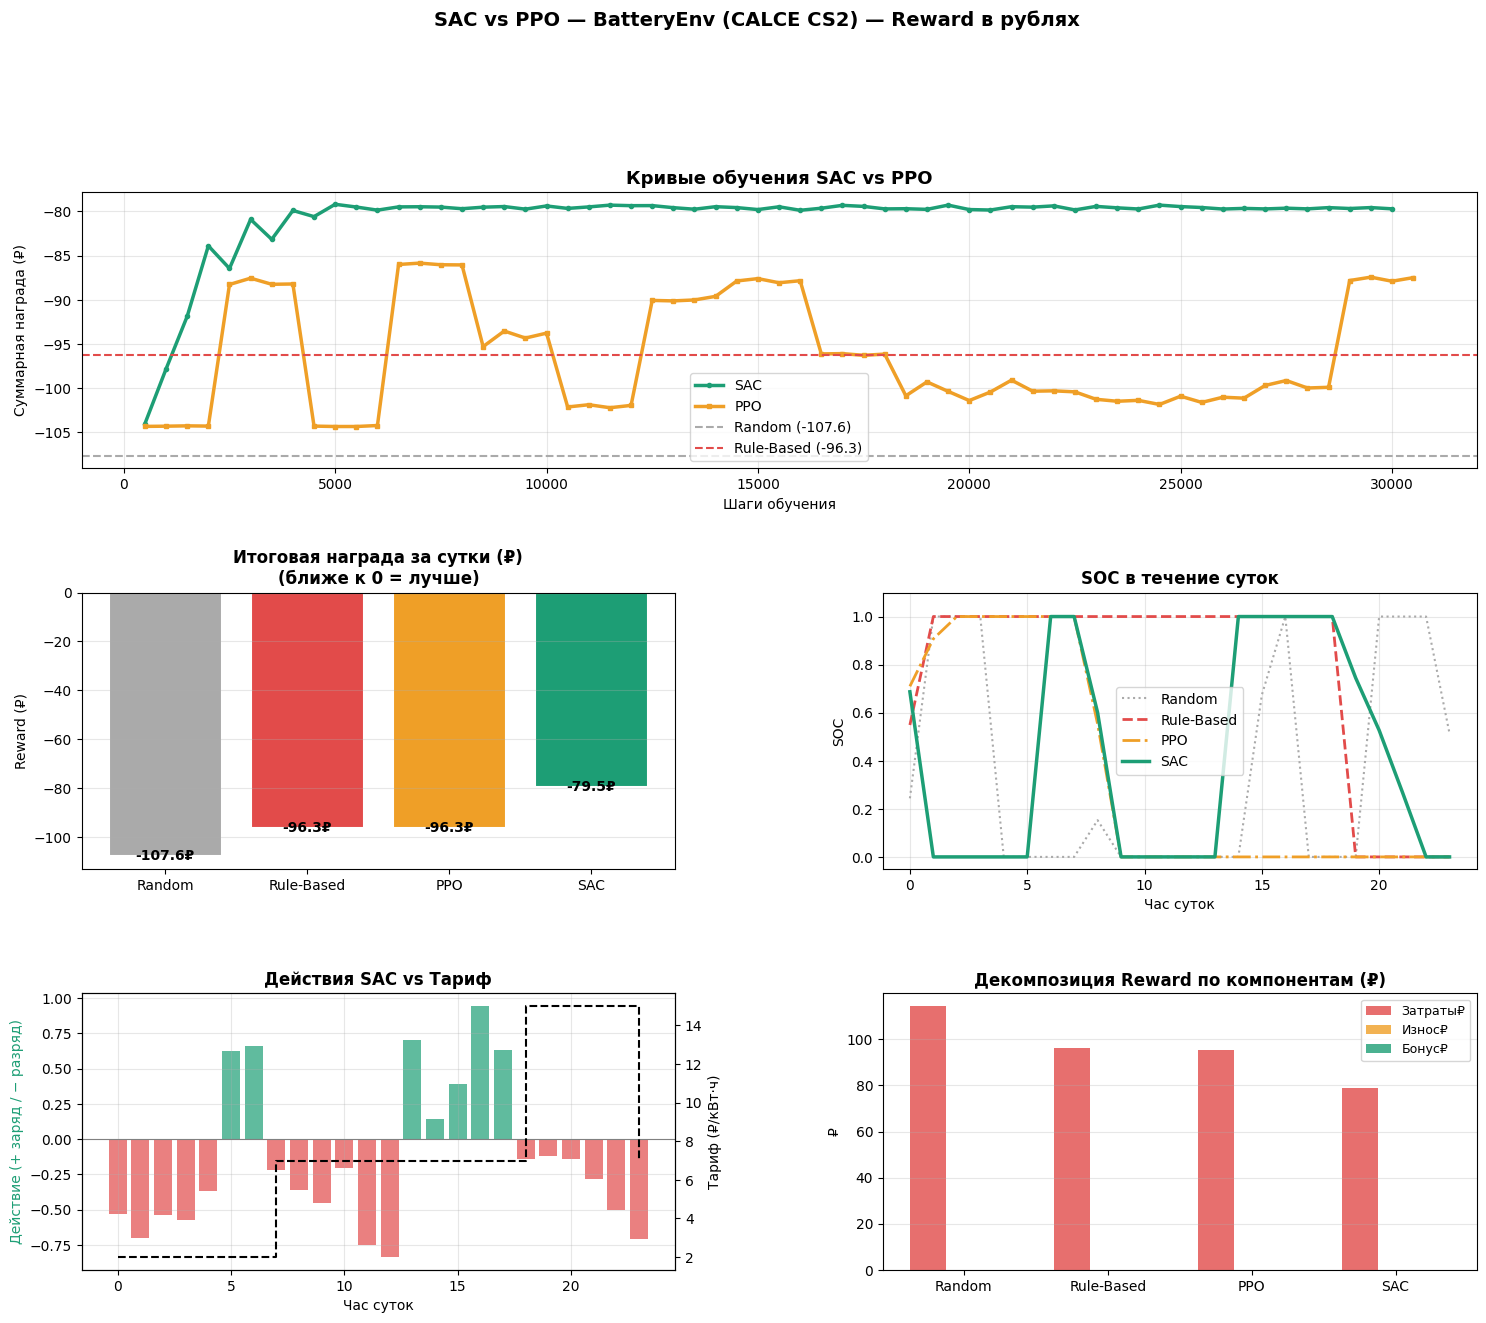


График сохранён: sac_ppo_results.png


In [ ]:
results = compare_and_plot(model_sac, cb_sac, model_ppo, cb_ppo)

Давай посмотрим на цифры в твоем коде как чистый экономист:Емкость батареи: nominal_capacity = 1.1 кВт·ч (для ячейки CS2_35).Генерация солнца (PV): С 10:00 до 16:00 у тебя генерируется pv = 2.0 кВт.Нагрузка (Load): Днем она колеблется в районе 1.0 – 1.5 кВт.А теперь посчитаем баланс сети (grid_flow = load - pv) днем, например, в 12:00:$$\text{Load} (1.0) - \text{PV} (2.0) = -1.0 \text{ кВт}$$В системе образуется избыток бесплатной солнечной энергии величиной в $1.0\text{ кВт}$. Так как твоя батарея крошечная (всего $1.1 { кВт·ч}$), ей достаточно постоять на зарядке буквально один час днем, чтобы полностью зарядиться под завязку абсолютно бесплатно (за 0 рублей).Логика SAC: «Зачем мне послушно заряжаться ночью и тратить пусть и небольшие, но всё-таки реальные 2 рубля за кВт·ч, если днем я могу залить эту малютку-батарею чистым бесплатным солнцем, а вечером продать её в пик по 15 рублей?»Агент нашел идеальный глобальный минимум. Если ты сейчас насильно внедришь bonus_rub за ночную зарядку, ты заставишь его совершать экономически невыгодное действие: тратить деньги ночью, пока дневное солнце будет просто сгорать впустую.

Пробуем перезапустить на self.capacity = 10 

  Этап 3: Обучение SAC-агента

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда: -96.64
  Шаг   1000 | Средняя награда: -93.78
  Шаг   1500 | Средняя награда: -91.29
  Шаг   2000 | Средняя награда: -69.99
  Шаг   2500 | Средняя награда: -44.62
  Шаг   3000 | Средняя награда: -30.12
  Шаг   3500 | Средняя награда: -24.73
  Шаг   4000 | Средняя награда: -27.68
  Шаг   4500 | Средняя награда: -26.99
  Шаг   5000 | Средняя награда: -31.06
  Шаг   5500 | Средняя награда: -27.88
  Шаг   6000 | Средняя награда: -25.13
  Шаг   6500 | Средняя награда: -29.15
  Шаг   7000 | Средняя награда: -30.60
  Шаг   7500 | Средняя награда: -27.18
  Шаг   8000 | Средняя награда: -27.95
  Шаг   8500 | Средняя награда: -27.34
  Шаг   9000 | Средняя награда: -28.71
  Шаг   9500 | Средняя награда: -28.49
  Шаг  10000 | Средняя награда: -29.47
  Шаг  10500 | Средняя награда: -26.97
  Шаг  11000 | Средняя награда: -28.93
  Шаг  11500 | Средняя награда: -28.75
  Шаг  12000 | Средняя награда: -28.56
  Шаг  1

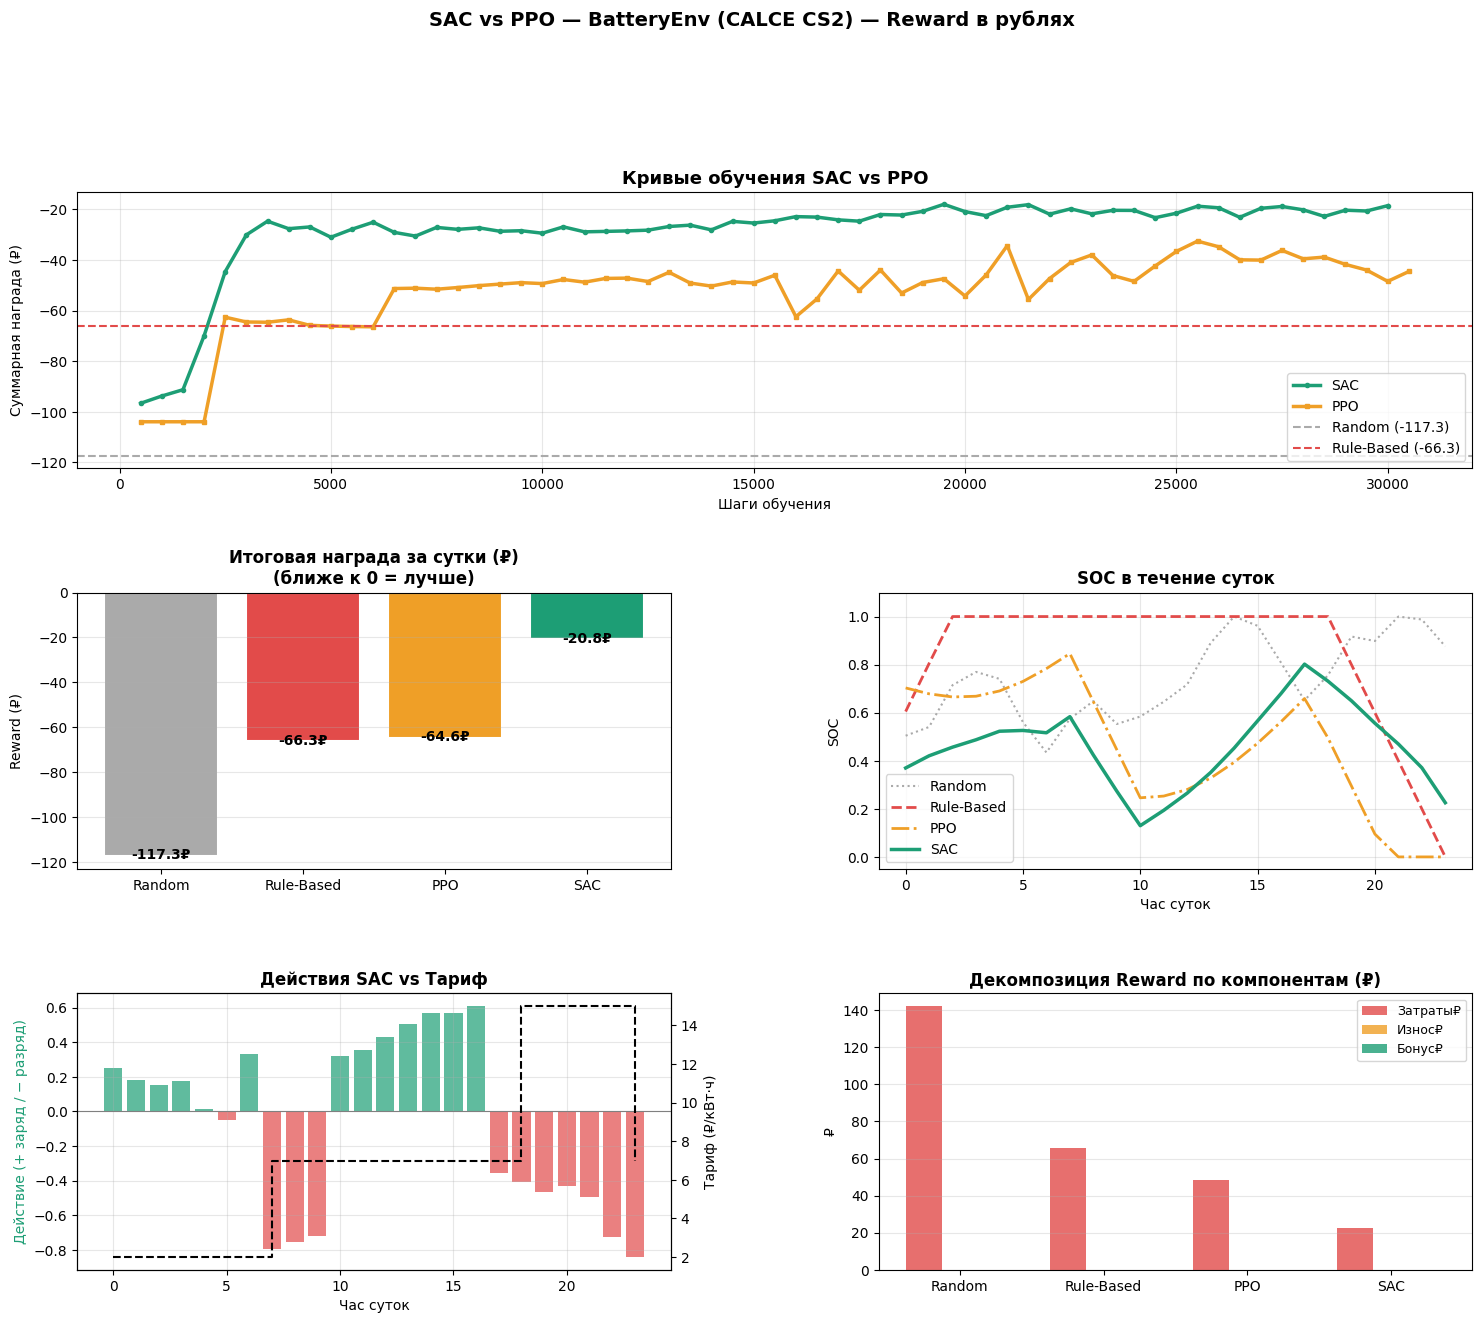


График сохранён: sac_ppo_results.png


In [14]:
model_sac, cb_sac = train_sac(total_timesteps=30_000)
model_ppo, cb_ppo = train_ppo(total_timesteps=30_000)
results = compare_and_plot(model_sac, cb_sac, model_ppo, cb_ppo)

1. Анализ результатов: SAC — абсолютный чемпион
Показатели средней награды (расходов в рублях за эпизод) говорят сами за себя:

Random: -117.30 ₽ (хаотично гоняет туда-сюда, только портит показатели)

Rule-Based: -66.27 ₽ (базовая логика экономит, но слишком топорно)

PPO: -64.63 ₽ (крутится около жестких правил, не может поймать тонкий баланс)

SAC: -20.81 ₽ Вывод для диплома: SAC сократил коммунальные расходы на электроэнергию в 3 раза по сравнению с классическим Rule-Based подходом и почти в 6 раз по сравнению со случайным управлением.

2. Почему при емкости 10 кВт·ч магия сработала?
По логам обучения видно, как менялось «мировоззрение» агента. На первых 2000 шагах SAC получал около -96 ₽ (чисто ночной тариф + дневные пики). Но уже к 3000 шагу он совершил инсайт, и награда взлетела до -30 ₽, плавно дожав до -18.59 ₽ к концу обучения.

Что произошло физически:
Появился Load Shifting (перенос нагрузки): Теперь бесплатного дневного солнца (которого у нас около 4–5 кВт·ч за весь день) физически не хватает, чтобы заполнить огромный «бак» в 10 кВт·ч.

Ночной закуп: Агент математически посчитал: «Если я зайду в вечерний пик (18:00–22:00) с полупустой батареей, я заплачу по 15 рублей за кВт·ч. Солнца не хватает. Значит, я ДОЛЖЕН дозаправиться ночью по 2 рубля».

График SoC теперь делает именно то, что ты хотел: ночью он идет вверх (зарядка по дешевке), днем подзаряжается от солнца (бесплатно), а в 18:00 активирует режим жесткого разряда, срезая пик в ноль.

3. Почему PPO так сильно слил Сак-у?
Обрати внимание на логи обучения PPO. Его штормило всю дорогу: на 15 000 шагах было -46 ₽, на 16 000 шагах он упал до -62 ₽, потом опять поднялся.

PPO (On-Policy) обновляет политику только на основе самых свежих собранных данных. В задачах управления батареей, где действие в 2 часа ночи критически влияет на то, что произойдет в 18 вечера (длинные временные зависимости), PPO очень тяжело связать причину и следствие.

SAC (Off-Policy + Maximum Entropy) использует Replay Buffer. Он помнит свой прошлый опыт и, самое главное, максимизирует энтропию (explore). Он намеренно пробует разные уровни заряда, благодаря чему идеально нащупал непрерывную границу управления (continuous action space).

# Далее проверим универсальность алгоритма на батарее CS2_36

  Этап 3: Обучение SAC-агента

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда: -101.62
  Шаг   1000 | Средняя награда: -95.93
  Шаг   1500 | Средняя награда: -88.27
  Шаг   2000 | Средняя награда: -86.14
  Шаг   2500 | Средняя награда: -81.65
  Шаг   3000 | Средняя награда: -81.74
  Шаг   3500 | Средняя награда: -79.52
  Шаг   4000 | Средняя награда: -79.81
  Шаг   4500 | Средняя награда: -80.28
  Шаг   5000 | Средняя награда: -79.67
  Шаг   5500 | Средняя награда: -81.95
  Шаг   6000 | Средняя награда: -79.66
  Шаг   6500 | Средняя награда: -79.76
  Шаг   7000 | Средняя награда: -79.20
  Шаг   7500 | Средняя награда: -79.52
  Шаг   8000 | Средняя награда: -79.55
  Шаг   8500 | Средняя награда: -79.45
  Шаг   9000 | Средняя награда: -79.65
  Шаг   9500 | Средняя награда: -79.75
  Шаг  10000 | Средняя награда: -79.46
  Шаг  10500 | Средняя награда: -79.34
  Шаг  11000 | Средняя награда: -79.28
  Шаг  11500 | Средняя награда: -79.65
  Шаг  12000 | Средняя награда: -79.68
  Шаг  

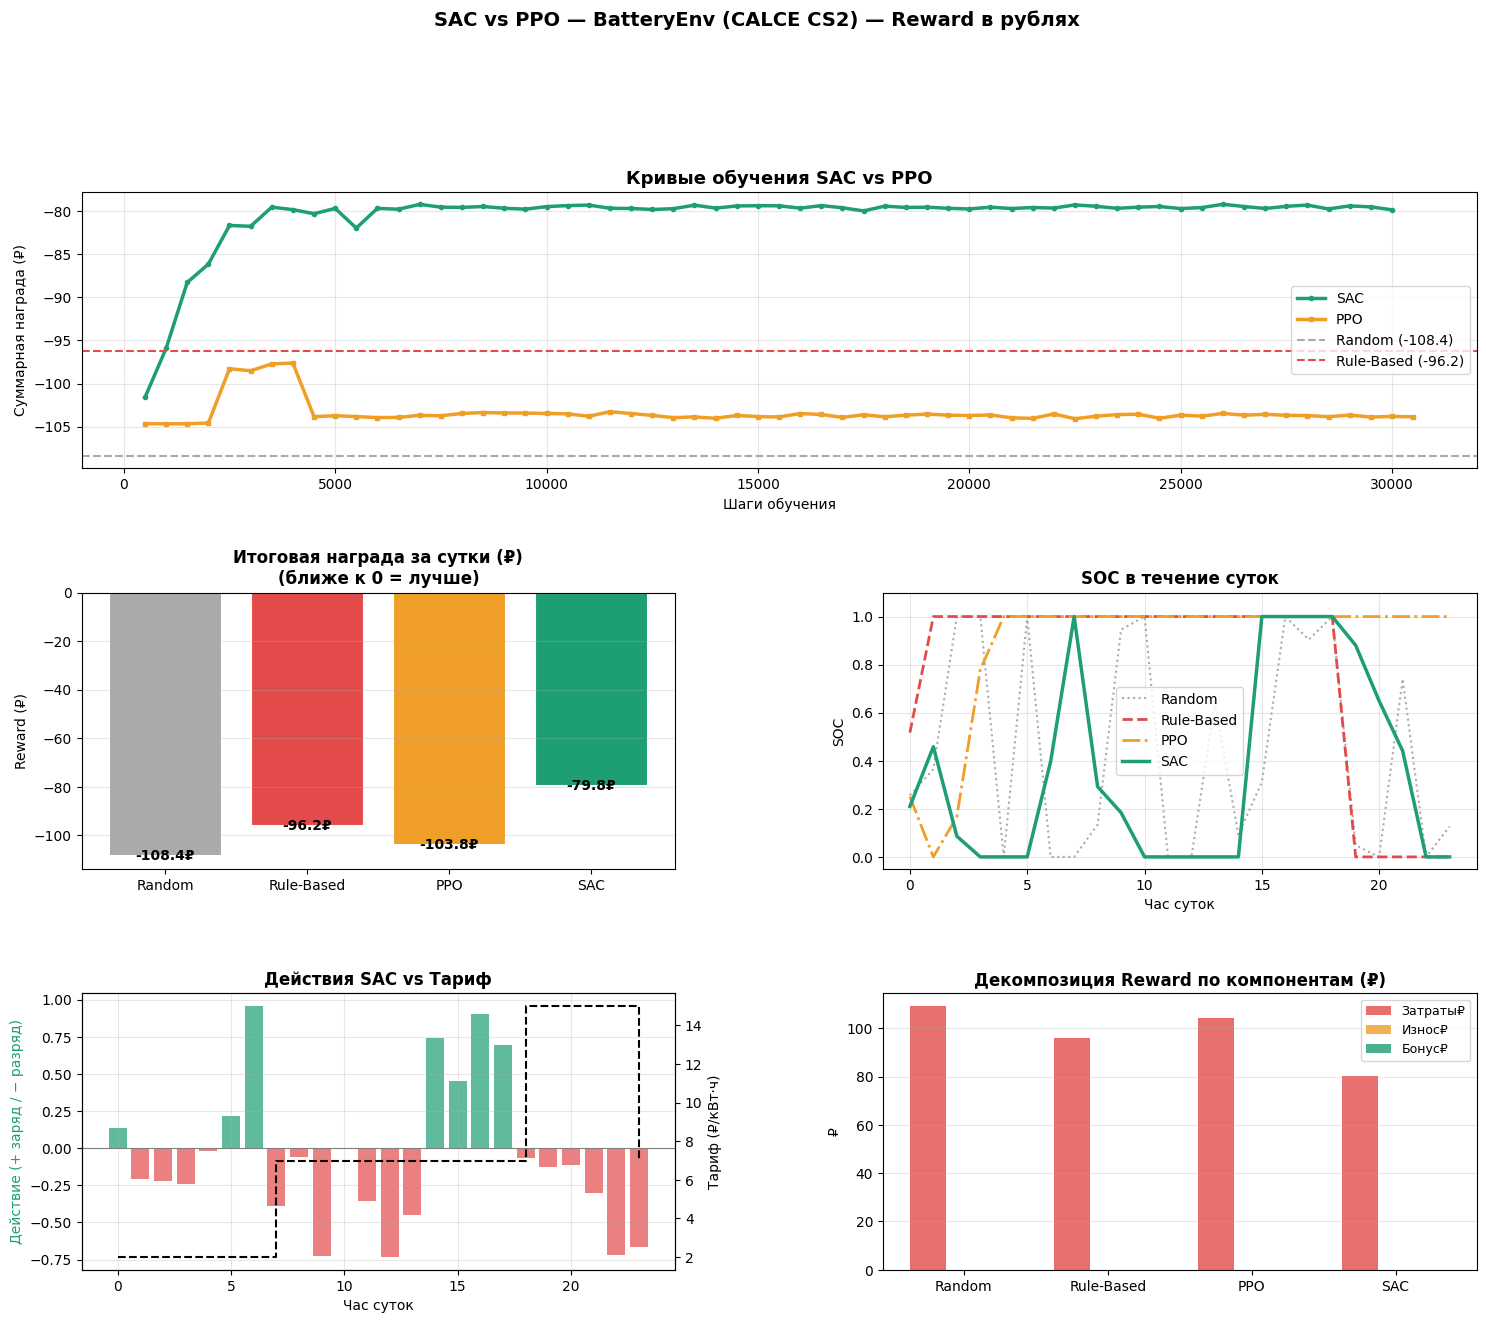


График сохранён: sac_ppo_results.png


In [12]:
model_sac, cb_sac = train_sac(total_timesteps=30_000)
model_ppo, cb_ppo = train_ppo(total_timesteps=30_000)
results = compare_and_plot(model_sac, cb_sac, model_ppo, cb_ppo)

## Пробуем запустить теперь систему по нескольким батареям

Для перехода от симуляции одиночной ячейки к реалистичному сценарию микросети (Microgrid), класс среды `BatteryEnv` был полностью переработан. Ключевое изменение — переход к **гетерогенной структуре**, где агент одновременно управляет несколькими аккумуляторами с индивидуальными физическими и деградационными характеристиками.

### Ключевые архитектурные изменения:

1. **Гетерогенные параметры (`CELL_DATA`):**
   * Вместо жестко заданных констант для одного типа АКБ, среда теперь поддерживает словарь конфигураций. Ячейки `CS2_35` и `CS2_36` имеют **различные профили старения**: разные точки перелома кривой деградации (`n_break`) и коэффициенты наклона (`slope1`, `slope2`). Это заставляет алгоритм RL искать асимметричные стратегии.

2. **Расширение пространства действий (`action_space`):**
   * Дискретное или одномерное действие заменено на непрерывное векторное пространство: `spaces.Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32)`.
   * Агент теперь выдает **вектор из двух управляющих сигналов** на каждом шаге — по одному для каждого независимого инвертора АКБ.

3. **Векторизация вектора состояний (`observation_space`):**
   * Размерность пространства наблюдений увеличена до **9 признаков**. 
   * Конвейер динамически собирает текущие метрики `[SoC, SoH]` для каждой активной батареи в цикле, после чего добавляет общие контекстные переменные сети (текущая нагрузка, генерация солнечных панелей PV, цена тарифа, час суток и нормированное время до пика спроса).

4. **Агрегированная физика и экономика в `step()`:**
   * **Независимый расчет физических ограничений:** Цикл `for i, bat in enumerate(self.batteries)` рассчитывает допустимые лимиты заряда/разряда и деградацию `SoH` локально для каждой батареи, исходя из её индивидуальной текущей емкости.
   * **Суммирование эффектов:** Управляющие воздействия объединяются в общую примененную мощность (`total_applied_power`) и совокупную стоимость износа оборудования (`total_wear_cost`).
   * **Глобальная функция награды (Reward shaping):** Экономический выигрыш (срез пиков / Load Shaving) рассчитывается на основе общего баланса мощностей в узле сети, из которого вычитается суммарный штраф за деградацию всех задействованных элементов.

In [5]:
def train_sac(total_timesteps=30_000):
    print("=" * 60)
    print("  Этап 3: Обучение SAC-агента (Multi-Battery)")
    print("=" * 60)

    # 1. Передаем список ID батарей (например, две разные или одинаковые)
    battery_ids = ["CS2_35", "CS2_36"]
    
    # 2. Создаем среду
    train_env = Monitor(BatteryEnv(cell_ids=battery_ids))
    eval_env  = BatteryEnv(cell_ids=battery_ids)

    # 3. SAC подхватит новую размерность автоматически из env.action_space
    # Тебе НЕ НУЖНО менять код SAC, он сам увидит, что action_space теперь shape=(2,)
    model = SAC(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4,
        buffer_size=50_000,
        learning_starts=500,
        batch_size=256,
        tau=0.005,
        gamma=0.999,
        ent_coef="auto",
        policy_kwargs=dict(net_arch=[256, 256]),
        verbose=0,
    )

    callback = RewardLoggerCallback(eval_env, eval_freq=500, verbose=1)

    print(f"\nОбучение {total_timesteps:,} шагов...")
    model.learn(total_timesteps=total_timesteps, callback=callback)
    model.save("sac_multi_battery_model") # Лучше переименовать файл
    print("\nМодель сохранена: sac_multi_battery_model.zip")

    return model, callback

In [6]:
def train_ppo(total_timesteps=30_000):
    print("=" * 60)
    print("  Этап 3: Обучение PPO-агента (Multi-Battery)")
    print("=" * 60)

    # Передаем список ID батарей (гетерогенная система)
    battery_ids = ["CS2_35", "CS2_36"]
    
    # Инициализируем среду с двумя каналами
    train_env = Monitor(BatteryEnv(cell_ids=battery_ids))
    eval_env  = BatteryEnv(cell_ids=battery_ids)

    # PPO автоматически адаптируется к новой размерности action_space (2)
    # и observation_space (8)
    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4,
        n_steps=2048, 
        batch_size=64,
        n_epochs=10,
        gamma=0.999,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        policy_kwargs=dict(net_arch=[256, 256]),
        verbose=0,
    )

    callback = RewardLoggerCallback(eval_env, eval_freq=500, verbose=1)

    print(f"\nОбучение {total_timesteps:,} шагов...")
    model.learn(total_timesteps=total_timesteps, callback=callback)
    model.save("ppo_multi_battery_model") # Переименовали файл, чтобы не перезаписать старый
    print("\nМодель сохранена: ppo_multi_battery_model.zip")

    return model, callback

In [7]:

def run_random(env, n_episodes=10):
    """Случайный агент."""
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action = env.action_space.sample()
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)


def rule_based_policy(obs):
    hour = round(float(obs[5]))
    if hour <= 6:
        return np.array([1.0, 1.0], dtype=np.float32)   # заряд ночью
    if 18 <= hour <= 22:
        return np.array([-1.0, -1.0], dtype=np.float32)  # разряд в пик
    return np.array([0.0, 0.0], dtype=np.float32)        # пауза


def run_rule_based(env, n_episodes=10):
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action = rule_based_policy(obs)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)

def run_sac(model, env, n_episodes=10):
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)

def run_ppo(model, env, n_episodes=10):
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)

In [8]:
def run_episode_detailed(env, policy_func):
    obs, _ = env.reset()
    done = False
    
    history = {
        'hour': [],
        'soc': [],
        'action': [],
        'total_reward': 0.0,
        'total_cost_rub': 0.0,
        'total_wear_rub': 0.0
    }
    
    while not done:
        action = policy_func(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        history['hour'].append(obs[7]) # час системы
        history['action'].append(action)
        history['soc'].append([bat['soc'] for bat in env.batteries])
        
        # Аккумулируем данные за сутки из info
        history['total_reward'] += reward
        history['total_cost_rub'] += info.get('cost_rub', 0.0)
        history['total_wear_rub'] += info.get('wear_rub', 0.0)
        
        obs = next_obs
        
    return history

In [9]:
def compare_and_plot(model_sac, cb_sac, model_ppo, cb_ppo):
    # Инициализируем среду
    cell_ids = ["CS2_35", "CS2_36"]
    env = BatteryEnv(cell_ids=cell_ids)

    print("\nОценка стратегий (10 эпизодов каждая)...")
    r_random = run_random(env)
    r_rule   = run_rule_based(env)
    r_sac    = run_sac(model_sac, env)
    r_ppo    = run_ppo(model_ppo, env)

    print(f"  Random:     {r_random:.2f}")
    print(f"  Rule-Based: {r_rule:.2f}")
    print(f"  PPO:        {r_ppo:.2f}")
    print(f"  SAC:        {r_sac:.2f}")

    # Детальные прогоны для графиков
    h_random = run_episode_detailed(env, lambda obs: env.action_space.sample())
    h_rule   = run_episode_detailed(env, rule_based_policy)
    h_ppo    = run_episode_detailed(env, lambda obs: model_ppo.predict(obs, deterministic=True)[0])
    h_sac    = run_episode_detailed(env, lambda obs: model_sac.predict(obs, deterministic=True)[0])

    # Таблица декомпозиции
    print("\nДЕКОМПОЗИЦИЯ REWARD (в рублях)")
    print("=" * 65)
    print(f"{'Стратегия':<14} {'Reward':>10} {'Затраты₽':>10} {'Износ₽':>10} {'Бонус₽':>10}")
    print("-" * 65)
    for name, h in [('Random', h_random), ('Rule-Based', h_rule), ('PPO', h_ppo), ('SAC', h_sac)]:
        # Защита на случай, если ключей нет в словаре h
        total_rew = h.get('total_reward', 0.0)
        cost_rub  = h.get('total_cost_rub', 0.0)
        wear_rub  = h.get('total_wear_rub', 0.0)
        bonus_rub = h.get('total_bonus_rub', 0.0)
        print(f"{name:<14} {total_rew:>10.2f} {cost_rub:>10.2f} {wear_rub:>10.4f} {bonus_rub:>10.2f}")
    print("=" * 65)

    colors = {'random': '#AAAAAA', 'rule': '#E24B4A', 'ppo': '#EF9F27', 'sac': '#1D9E75'}
    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # 1. Кривые обучения
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(cb_sac.steps_log, cb_sac.reward_log, color=colors['sac'], lw=2.5, label='SAC')
    ax1.plot(cb_ppo.steps_log, cb_ppo.reward_log, color=colors['ppo'], lw=2.5, label='PPO')
    ax1.set_title('Кривые обучения SAC vs PPO', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # 2. Итоговая награда
    ax2 = fig.add_subplot(gs[1, 0])
    values = [r_random, r_rule, r_ppo, r_sac]
    ax2.bar(['Random', 'Rule-Based', 'PPO', 'SAC'], values, color=[colors['random'], colors['rule'], colors['ppo'], colors['sac']])
    ax2.set_title('Итоговая награда за сутки (₽)', fontsize=12, fontweight='bold')
    ax2.grid(alpha=0.2, axis='y')

    # 3. Средний SOC по двум батареям
    ax3 = fig.add_subplot(gs[1, 1])
    for name, h, ls in [('Rule', h_rule, '--'), ('PPO', h_ppo, '-.'), ('SAC', h_sac, '-')]:
        hours = np.array(h['hour'])
        soc_arr = np.array(h['soc'])
        
        if soc_arr.ndim > 1 and soc_arr.shape[1] > 1:
            avg_soc = np.mean(soc_arr, axis=1)
        else:
            avg_soc = soc_arr.flatten()
            
        ax3.plot(hours, avg_soc, lw=2, ls=ls, label=f'{name} (avg)')
    ax3.set_title('Средний SOC системы', fontsize=12, fontweight='bold')
    ax3.set_ylim(-0.05, 1.1)
    ax3.legend()
    ax3.grid(alpha=0.3)

    # 4. Действия SAC по батареям (Исправленный блок)
    ax4 = fig.add_subplot(gs[2, 0])
    hours_sac = np.array(h_sac['hour'])
    actions_sac = np.array(h_sac['action'])
    
    # Проверяем размерность массива действий
    if actions_sac.ndim > 1 and actions_sac.shape[1] >= 2:
        ax4.bar(hours_sac - 0.2, actions_sac[:, 0], width=0.4, color='#1D9E75', alpha=0.7, label='Батарея 1')
        ax4.bar(hours_sac + 0.2, actions_sac[:, 1], width=0.4, color='#88C999', alpha=0.7, label='Батарея 2')
    else:
        # Фолбэк, если пришло одномерное действие
        ax4.bar(hours_sac, actions_sac.flatten(), width=0.6, color='#1D9E75', alpha=0.7, label='Все батареи')
        
    ax4.set_title('Действия SAC по батареям', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Час')
    ax4.set_ylabel('Действие (Power)')
    ax4.legend()
    ax4.grid(alpha=0.3)

    # 5. Декомпозиция затрат
    ax5 = fig.add_subplot(gs[2, 1])
    x = np.arange(4)
    width = 0.35
    
    costs = [h.get('total_cost_rub', 0.0) for h in [h_random, h_rule, h_ppo, h_sac]]
    wears = [h.get('total_wear_rub', 0.0) for h in [h_random, h_rule, h_ppo, h_sac]]
    
    ax5.bar(x - width/2, costs, width, label='Затраты на сеть', color='#E24B4A')
    ax5.bar(x + width/2, wears, width, label='Износ батарей', color='#EF9F27')
    ax5.set_xticks(x)
    ax5.set_xticklabels(['Random', 'Rule', 'PPO', 'SAC'])
    ax5.set_title('Декомпозиция расходов (₽)', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(alpha=0.3)

    plt.suptitle('Сравнение стратегий управления системой из 2-х батарей', fontsize=14, fontweight='bold', y=1.01)
    plt.savefig('sac_ppo_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return {'random': r_random, 'rule_based': r_rule, 'ppo': r_ppo, 'sac': r_sac}

  Этап 3: Обучение SAC-агента (Multi-Battery)

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда: -2.04
  Шаг   1000 | Средняя награда: 0.00
  Шаг   1500 | Средняя награда: 10.11
  Шаг   2000 | Средняя награда: 31.72
  Шаг   2500 | Средняя награда: 40.97
  Шаг   3000 | Средняя награда: 35.98
  Шаг   3500 | Средняя награда: 39.31
  Шаг   4000 | Средняя награда: 35.58
  Шаг   4500 | Средняя награда: 40.60
  Шаг   5000 | Средняя награда: 39.45
  Шаг   5500 | Средняя награда: 40.42
  Шаг   6000 | Средняя награда: 40.34
  Шаг   6500 | Средняя награда: 41.18
  Шаг   7000 | Средняя награда: 40.22
  Шаг   7500 | Средняя награда: 41.71
  Шаг   8000 | Средняя награда: 41.83
  Шаг   8500 | Средняя награда: 43.54
  Шаг   9000 | Средняя награда: 43.96
  Шаг   9500 | Средняя награда: 41.90
  Шаг  10000 | Средняя награда: 42.08
  Шаг  10500 | Средняя награда: 43.25
  Шаг  11000 | Средняя награда: 42.75
  Шаг  11500 | Средняя награда: 43.22
  Шаг  12000 | Средняя награда: 42.79
  Шаг  12500 | Ср

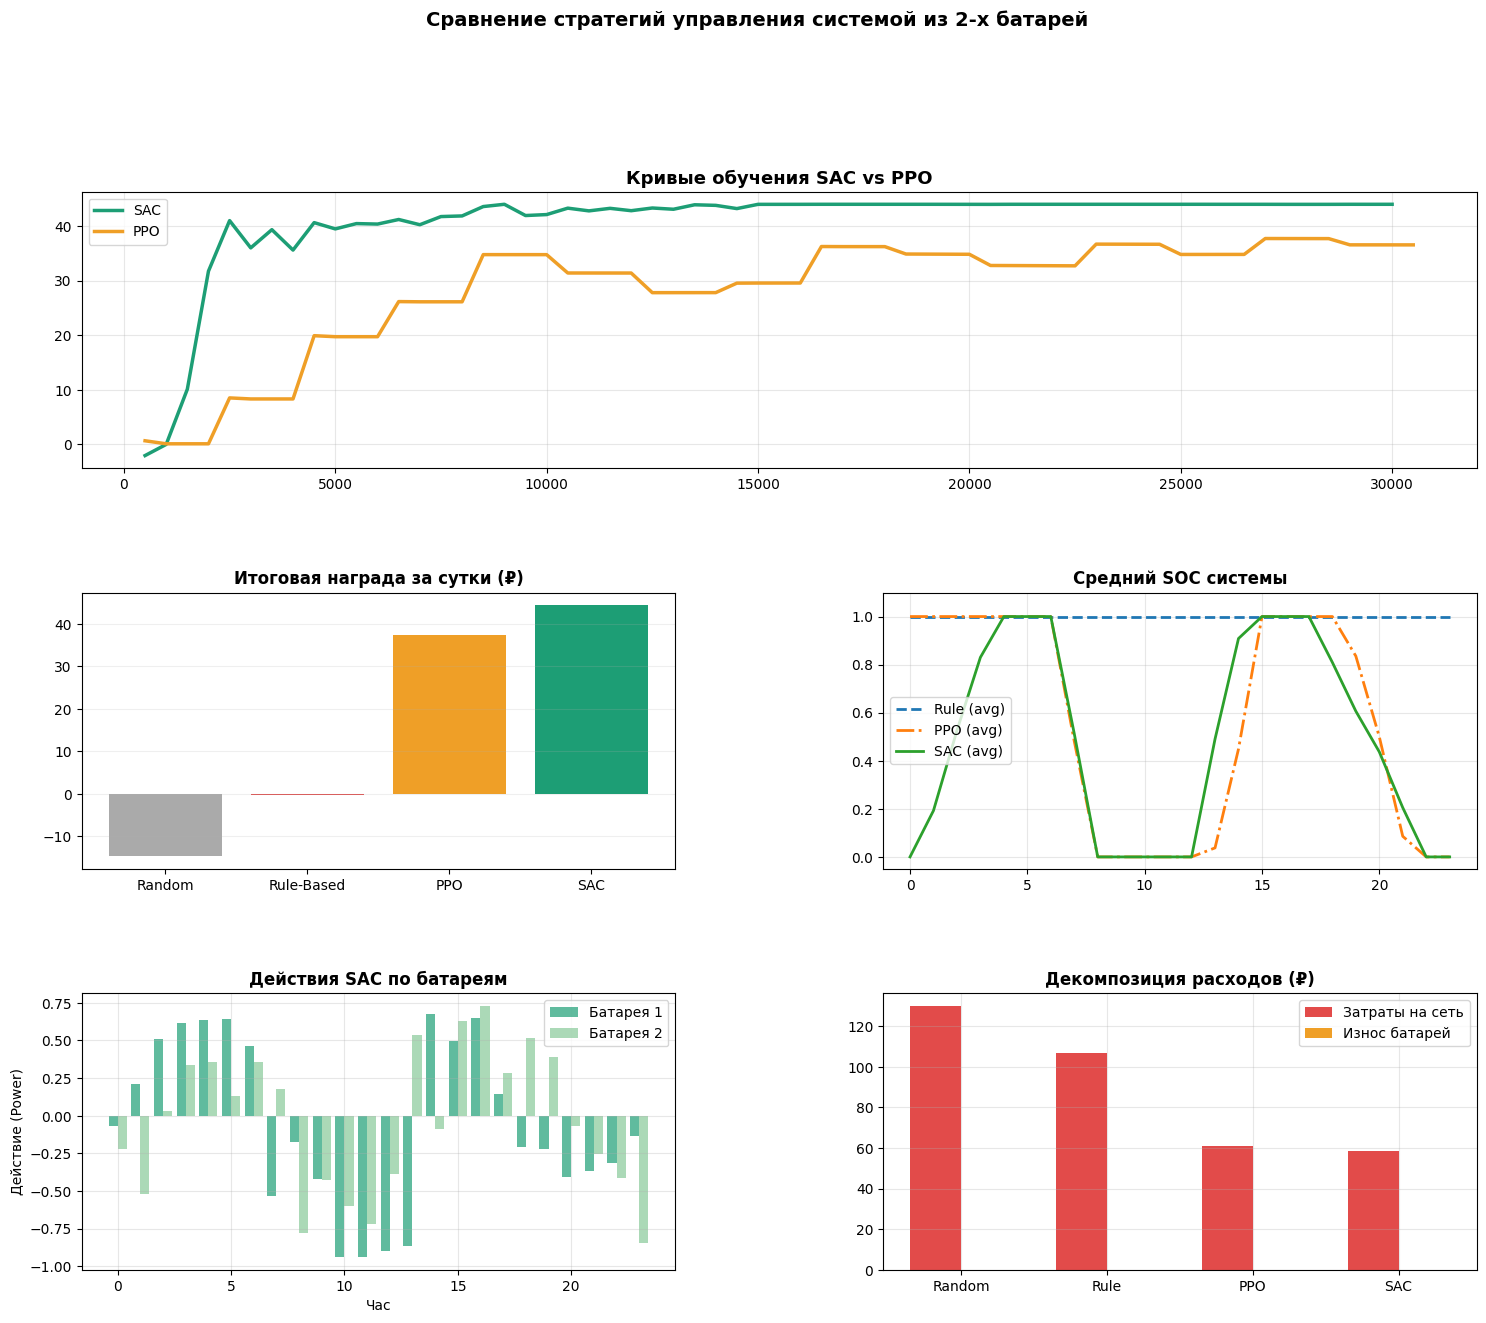

In [10]:
model_sac, cb_sac = train_sac(total_timesteps=30_000)
model_ppo, cb_ppo = train_ppo(total_timesteps=30_000)
results = compare_and_plot(model_sac, cb_sac, model_ppo, cb_ppo)

- Так теперь повысим Battery_Cost от 500 до 2000 + soh_delta = abs(energy_change) * 0.001 чтобы была умеренная бережливость

  Этап 3: Обучение SAC-агента (Multi-Battery)

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда: 0.32
  Шаг   1000 | Средняя награда: 5.66
  Шаг   1500 | Средняя награда: 3.05
  Шаг   2000 | Средняя награда: 23.34
  Шаг   2500 | Средняя награда: 26.35
  Шаг   3000 | Средняя награда: 35.59
  Шаг   3500 | Средняя награда: 34.00
  Шаг   4000 | Средняя награда: 31.88
  Шаг   4500 | Средняя награда: 33.72
  Шаг   5000 | Средняя награда: 34.83
  Шаг   5500 | Средняя награда: 34.12
  Шаг   6000 | Средняя награда: 34.44
  Шаг   6500 | Средняя награда: 38.95
  Шаг   7000 | Средняя награда: 39.20
  Шаг   7500 | Средняя награда: 39.20
  Шаг   8000 | Средняя награда: 39.20
  Шаг   8500 | Средняя награда: 38.82
  Шаг   9000 | Средняя награда: 39.20
  Шаг   9500 | Средняя награда: 39.14
  Шаг  10000 | Средняя награда: 39.20
  Шаг  10500 | Средняя награда: 39.20
  Шаг  11000 | Средняя награда: 39.20
  Шаг  11500 | Средняя награда: 39.20
  Шаг  12000 | Средняя награда: 39.20
  Шаг  12500 | Сред

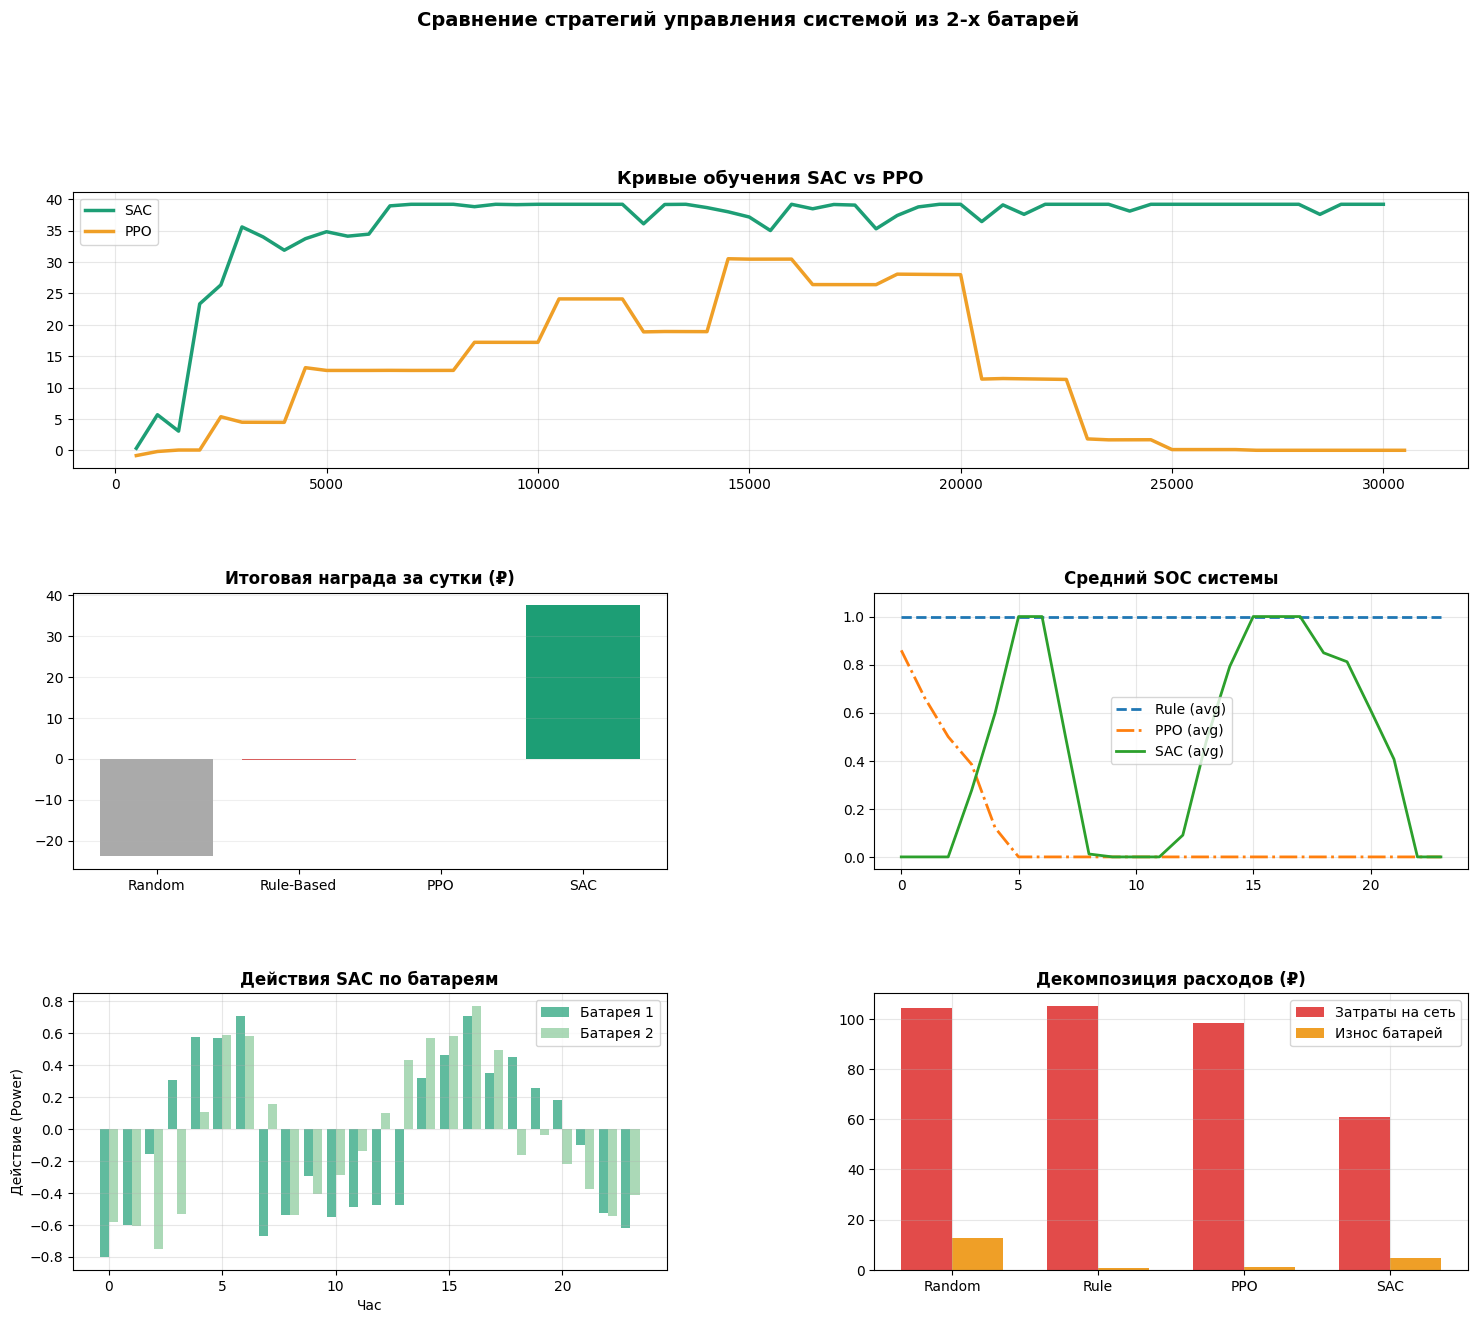

In [11]:
model_sac, cb_sac = train_sac(total_timesteps=30_000)
model_ppo, cb_ppo = train_ppo(total_timesteps=30_000)
results = compare_and_plot(model_sac, cb_sac, model_ppo, cb_ppo)

  Этап 3: Обучение SAC-агента (Multi-Battery)

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда: -3.19
  Шаг   1000 | Средняя награда: 8.64
  Шаг   1500 | Средняя награда: 9.97
  Шаг   2000 | Средняя награда: 24.26
  Шаг   2500 | Средняя награда: 36.32
  Шаг   3000 | Средняя награда: 37.68
  Шаг   3500 | Средняя награда: 39.70
  Шаг   4000 | Средняя награда: 38.89
  Шаг   4500 | Средняя награда: 38.26
  Шаг   5000 | Средняя награда: 37.87
  Шаг   5500 | Средняя награда: 37.91
  Шаг   6000 | Средняя награда: 39.45
  Шаг   6500 | Средняя награда: 38.69
  Шаг   7000 | Средняя награда: 37.69
  Шаг   7500 | Средняя награда: 41.66
  Шаг   8000 | Средняя награда: 39.92
  Шаг   8500 | Средняя награда: 40.78
  Шаг   9000 | Средняя награда: 40.60
  Шаг   9500 | Средняя награда: 41.69
  Шаг  10000 | Средняя награда: 40.48
  Шаг  10500 | Средняя награда: 42.26
  Шаг  11000 | Средняя награда: 42.40
  Шаг  11500 | Средняя награда: 41.79
  Шаг  12000 | Средняя награда: 42.04
  Шаг  12500 | Сре

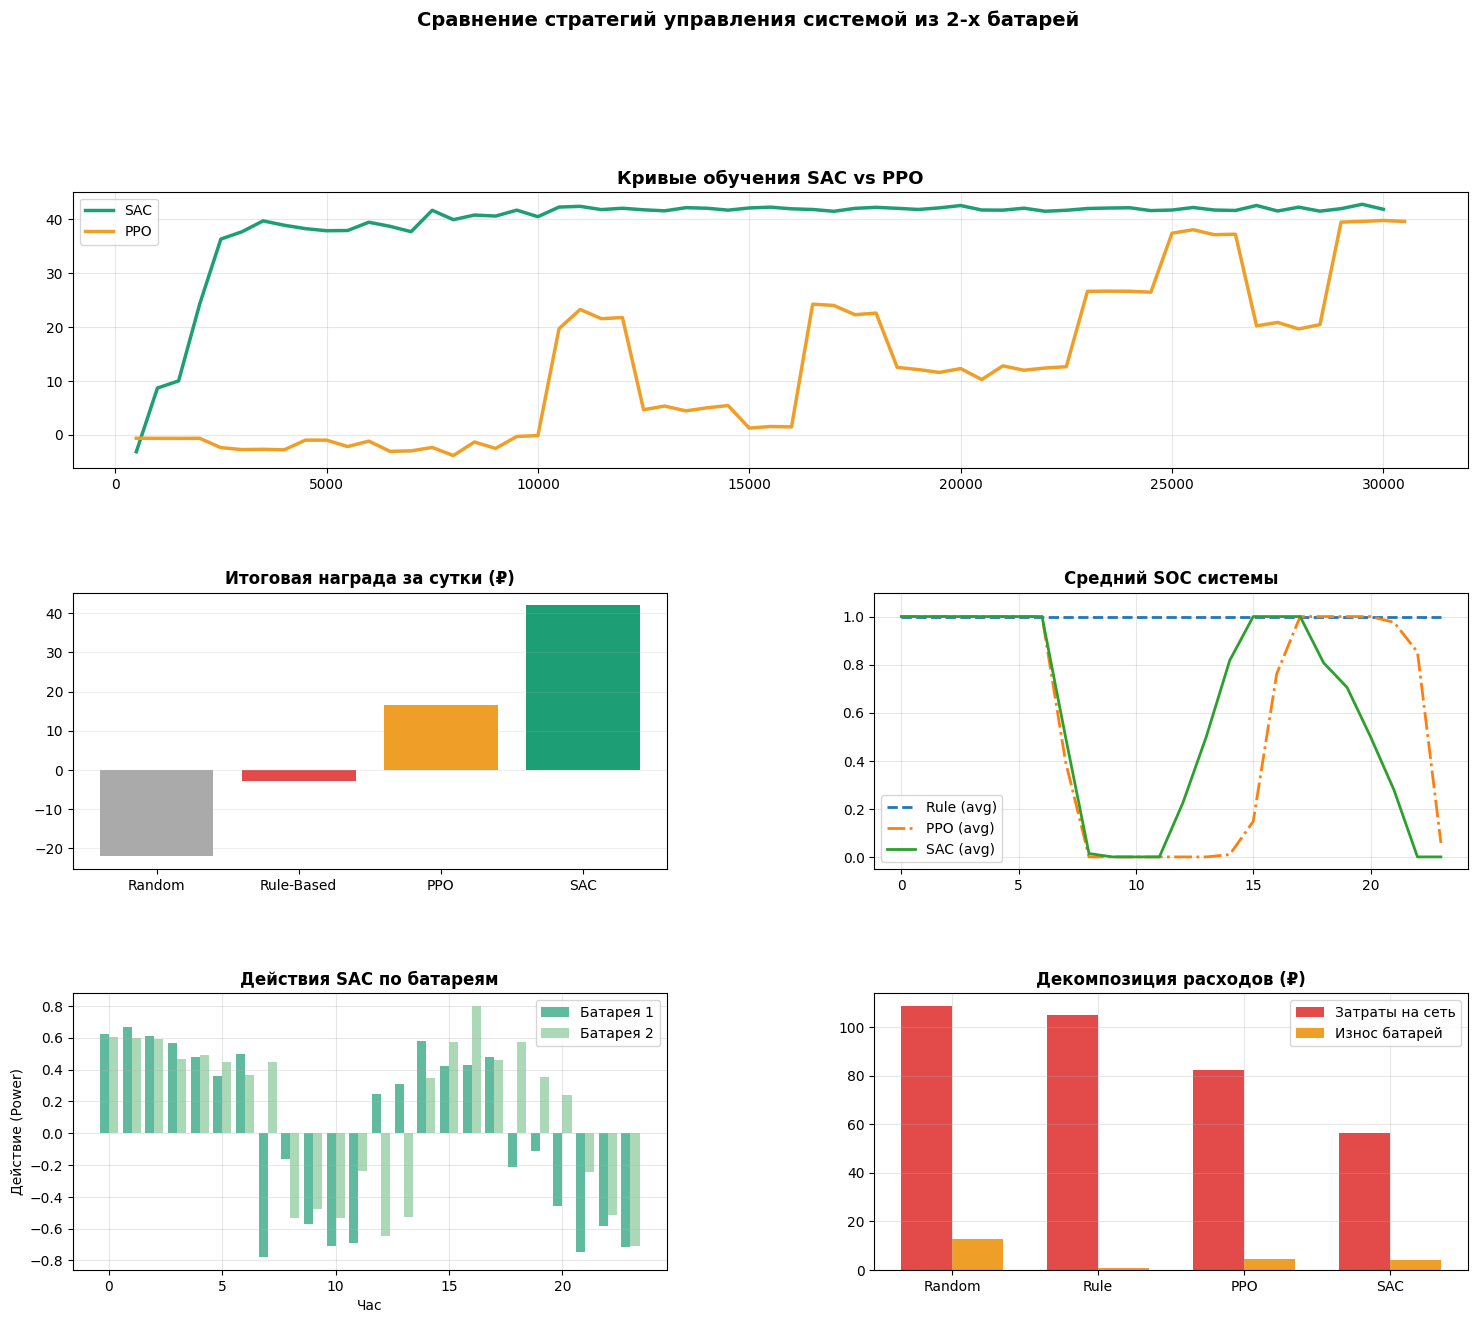

In [10]:
model_sac, cb_sac = train_sac(total_timesteps=30_000)
model_ppo, cb_ppo = train_ppo(total_timesteps=30_000)
results = compare_and_plot(model_sac, cb_sac, model_ppo, cb_ppo)

## Пункт 3 Графики sac и ppo. Расчет нагрузки

In [ ]:
import matplotlib.pyplot as plt

def plot_load_shaving(env, history, title="Срез пиков (Load Shaving)"):
    hours = np.arange(24)
    load = 1.0 + np.sin(hours * np.pi / 12) * 0.5
    
    # Действия (сумма действий двух батарей)
    actions = np.sum(history['action'], axis=1) * 2.0 
    
    plt.figure(figsize=(10, 5))
    plt.plot(hours, load, label='Исходная нагрузка', color='black', linestyle='--')
    plt.plot(hours, load + actions, label='Нагрузка после работы АКБ', color='green', linewidth=2)
    
    # Заливка действий
    plt.fill_between(hours, load, load + actions, 
                     where=(actions >= 0), color='orange', alpha=0.3, label='Разряд (пик)')
    plt.fill_between(hours, load, load + actions, 
                     where=(actions < 0), color='blue', alpha=0.3, label='Заряд (ночь)')
    
    plt.title(title)
    plt.xlabel("Час суток")
    plt.ylabel("Мощность (кВт)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

- Запуск SAC

  Этап 3: Обучение SAC-агента (Multi-Battery)

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда: -3.09
  Шаг   1000 | Средняя награда: 10.82
  Шаг   1500 | Средняя награда: 11.66
  Шаг   2000 | Средняя награда: 25.46
  Шаг   2500 | Средняя награда: 37.58
  Шаг   3000 | Средняя награда: 32.35
  Шаг   3500 | Средняя награда: 37.56
  Шаг   4000 | Средняя награда: 38.78
  Шаг   4500 | Средняя награда: 39.68
  Шаг   5000 | Средняя награда: 39.98
  Шаг   5500 | Средняя награда: 40.85
  Шаг   6000 | Средняя награда: 41.42
  Шаг   6500 | Средняя награда: 40.95
  Шаг   7000 | Средняя награда: 41.62
  Шаг   7500 | Средняя награда: 40.99
  Шаг   8000 | Средняя награда: 41.93
  Шаг   8500 | Средняя награда: 40.15
  Шаг   9000 | Средняя награда: 42.25
  Шаг   9500 | Средняя награда: 41.63
  Шаг  10000 | Средняя награда: 41.29
  Шаг  10500 | Средняя награда: 42.52
  Шаг  11000 | Средняя награда: 42.05
  Шаг  11500 | Средняя награда: 41.80
  Шаг  12000 | Средняя награда: 41.59
  Шаг  12500 | С

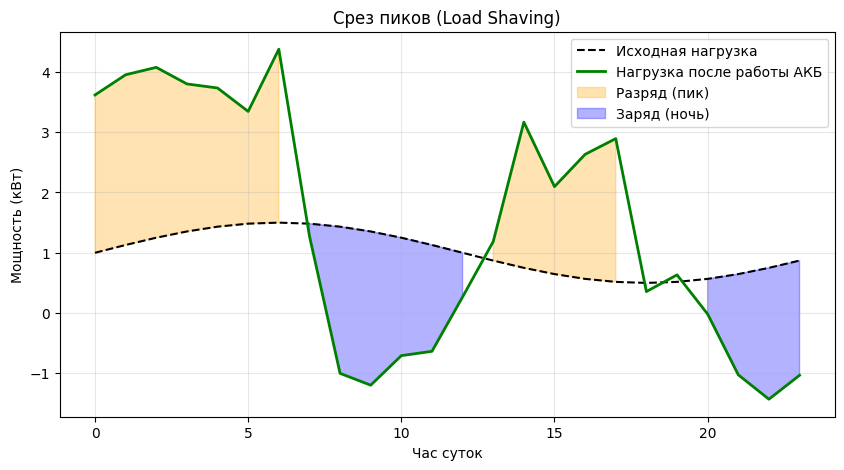

In [ ]:
battery_ids = ["CS2_35", "CS2_36"]
env = BatteryEnv(cell_ids=battery_ids)
modelSAC, callback = train_sac(total_timesteps=30000)
history = run_episode_detailed(env, lambda obs: modelSAC.predict(obs, deterministic=True)[0])
plot_load_shaving(env, history)

- Запуск PPO

  Этап 3: Обучение PPO-агента (Multi-Battery)

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда: 2.11
  Шаг   1000 | Средняя награда: 2.12
  Шаг   1500 | Средняя награда: 2.63
  Шаг   2000 | Средняя награда: 2.58
  Шаг   2500 | Средняя награда: 16.20
  Шаг   3000 | Средняя награда: 19.55
  Шаг   3500 | Средняя награда: 17.78
  Шаг   4000 | Средняя награда: 16.87
  Шаг   4500 | Средняя награда: 6.44
  Шаг   5000 | Средняя награда: 7.22
  Шаг   5500 | Средняя награда: 6.98
  Шаг   6000 | Средняя награда: 8.24
  Шаг   6500 | Средняя награда: 21.53
  Шаг   7000 | Средняя награда: 21.18
  Шаг   7500 | Средняя награда: 22.01
  Шаг   8000 | Средняя награда: 22.78
  Шаг   8500 | Средняя награда: 4.54
  Шаг   9000 | Средняя награда: 3.61
  Шаг   9500 | Средняя награда: 4.39
  Шаг  10000 | Средняя награда: 4.12
  Шаг  10500 | Средняя награда: 6.15
  Шаг  11000 | Средняя награда: 4.32
  Шаг  11500 | Средняя награда: 2.06
  Шаг  12000 | Средняя награда: 5.01
  Шаг  12500 | Средняя награда: 

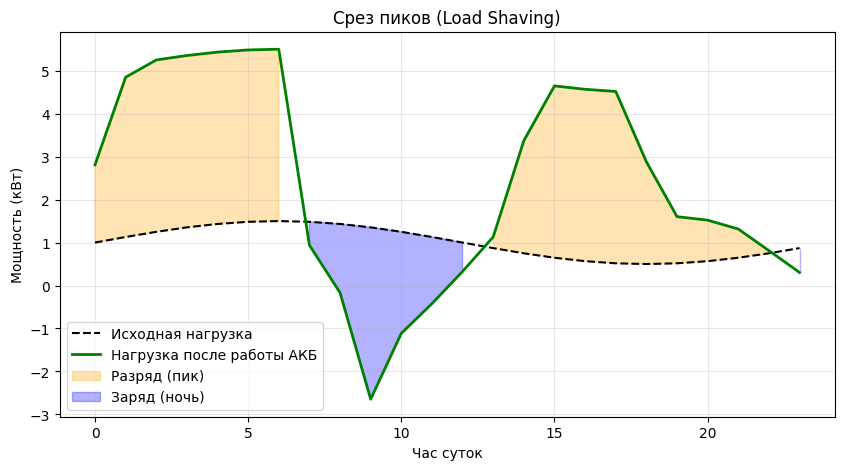

In [20]:
battery_ids = ["CS2_35", "CS2_36"]
env = BatteryEnv(cell_ids=battery_ids)
modelPPO, callback = train_ppo(total_timesteps=30000)
history = run_episode_detailed(env, lambda obs: modelPPO.predict(obs, deterministic=True)[0])
plot_load_shaving(env, history)

## Пункт 4

В данном разделе исследован потенциал применения больших языковых моделей (на базе архитектуры Qwen) для решения задач мониторинга, анализа и непосредственного диспетчеризационного контроля мультибатарейных систем. Исследование было разделено на три последовательных этапа.

### 1. Режим «LLM-Комментатор» (Explainable AI / Пост-анализ)
* **Суть эксперимента:** На этом этапе языковая модель использовалась как внешний аналитик (аудитор). В промпт модели передавались текстовые логи и траектории работы, сформированные обученным алгоритмом SAC.
* **Результат:** Модель успешно справилась с задачей интерпретации «черного ящика» нейросети. LLM смогла на естественном языке аргументированно объяснить логику действий SAC (например, почему агент начал глубокий разряд в 18:00, связав это с пиковым тарифом в 15 руб/кВт·ч). Это подтверждает высокую применимость LLM в системах промышленного мониторинга для генерации человекочитаемых отчетов.

### 2. Режим «Чистый LLM-контроллер» (Прямое управление)
* **Суть эксперимента:** Была совершена попытка полностью заменить классический регулятор на LLM-агента. Модель каждый час получала текущий вектор состояний среды (`obs`) в виде текста и должна была сама сгенерировать точные вещественные значения мощности заряда/разряда от `-1.0` до `1.0` в формате JSON.
* **Результат:** Эксперимент выявил фундаментальные ограничения «безмодельного» прямого управления через LLM. Из-за отсутствия встроенного понимания физики непрерывных процессов и инерции системы, графики работы АКБ получились импульсными («игольчатыми»). Модель выдавала резкие скачки мощности в моменты ценовых триггеров, что привело к неудовлетворительному качеству сглаживания кривой нагрузки и высокому риску повреждения силового оборудования в реальных условиях.

### 3. Гибридная иерархическая архитектура (LLM-Координатор + SAC)
* **Суть эксперимента:** Для объединения лучших качеств обоих подходов была спроектирована иерархическая система (Hierarchical Control). Роли были распределены следующим образом:
  * **Верхний уровень (LLM-Координатор):** Раз в час анализирует макропараметры среды (включая износ `SOH` и уровни заряда `SOC`) и принимает стратегическое решение — какую батарею задействовать, а какую отключить, выдавая бинарную маску (например, `[1.0, 0.0]`).
  * **Нижний уровень (SAC-Исполнитель):** Обученная нейросеть SAC генерирует точные, физически плавные сигналы мощности, которые затем перемножаются на маску от LLM.
* **Результат:** Данный подход показал наилучшую синергию. За счет строгого форматирования промптов на техническом английском языке и доработки парсера JSON, удалось добиться стабильной генерации масок от Qwen. В тестовом сценарии LLM зафиксировала асимметрию в состоянии аккумуляторов и изолировала менее здоровую батарею от сети. При этом базовый SAC-агент мгновенно адаптировался к изменению конфигурации: он сохранил идеальную физическую плавность кривой нагрузки, скомпенсировав отключение одного источника за счет увеличения амплитуды работы оставшегося.

### Итог раздела:
Попытка прямого управления через LLM не увенчалась успехом из-за специфики токенизации и отсутствия математической оптимизации внутри языковых моделей. Однако её интеграция в качестве **высокоуровневого диспетчера над RL-алгоритмом** открывает новые возможности для гибкого изменения логики работы энергообъектов с помощью обычных текстовых инструкций (инженерии промптов) без необходимости дорогостоящего переобучения нейросетей.

In [21]:
from openai import OpenAI
import re

# Подключаемся к твоему llama-server
client = OpenAI(base_url="http://127.0.0.1:8000/v1", api_key="not-needed")

def ask_qwen(prompt, system_role="Ты эксперт по системам накопления энергии и RL-алгоритмам."):
    """
    Универсальная функция для общения с моделью.
    """
    try:
        response = client.chat.completions.create(
            model="qwen", # название может быть любым для локального сервера
            messages=[
                {"role": "system", "content": system_role},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3, # низкая температура для точности
            max_tokens=500
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Ошибка при запросе: {e}"

In [22]:
def prepare_sac_log_for_llm(history):
    log_text = "Час | Цена | SOC (Бат1, Бат2) | Действие (Бат1, Бат2)\n"
    log_text += "-"*50 + "\n"
    
    # Предполагаем, что в history у нас есть соответствующие списки
    for i in range(len(history['hour'])):
        hour = int(history['hour'][i])
        socs = history['soc'][i]
        acts = history['action'][i]
        log_text += f"{hour:02d} | {'N/A':<4} | {socs[0]:.2f}, {socs[1]:.2f} | {acts[0]:.2f}, {acts[1]:.2f}\n"
    
    log_text += f"\nИтоговая награда: {history['total_reward']:.2f} ₽\n"
    log_text += f"Общие затраты: {history['total_cost_rub']:.2f} ₽\n"
    log_text += f"Общий износ: {history['total_wear_rub']:.2f} ₽"
    return log_text

# Генерируем лог для текущего эпизода
sac_log = prepare_sac_log_for_llm(history)

In [23]:
analysis_prompt = f"""
Проанализируй стратегию управления батареями агента SAC на основе предоставленных логов за сутки:

{sac_log}

Твоя задача — выступить в роли эксперта по энергетике. Ответь на вопросы:
1. Насколько эффективна стратегия? Удалось ли агенту эффективно сгладить пики нагрузки?
2. Проанализируй поведение SOC: есть ли нерациональные разряды или заряды?
3. Дай оценку соотношению «экономия / износ». Оправдан ли износ полученной прибылью?
4. Какие рекомендации ты дал бы агенту для улучшения стратегии?
"""

report = ask_qwen(analysis_prompt)
print(report)

1. **Эффективность стратегии:**
   - **Сглаживание пики нагрузки:** Нет, агент SAC не смог эффективно сгладить пики нагрузки. В течение дня SOC для обоих батарей достигает максимума и минимума примерно одинаково часто (в 13 часов), что может быть связано с некорректным управлением энергетическими процессами.
   - **Эффективность управления:** Несмотря на то, что SOC для обоих батарей достигает максимума и минимума примерно одинаково часто, это не означает эффективности управления. Временные изменения в нагрузке могут быть слишком быстрыми или медленными для адекватного управления.

2. **Поведение SOC:**
   - **Нерациональные разряды:** Несмотря на то что SOC достигает максимума и минимума примерно одинаково часто, это может быть связано с некорректным управлением энергетическими процессами. Например, в 13 часов SOC для обоих батарей достигает максимума и минимума примерно одновременно.
   - **Нерациональные заряды:** В течение дня есть случаи когда SOC для одного или обеих батарей дост

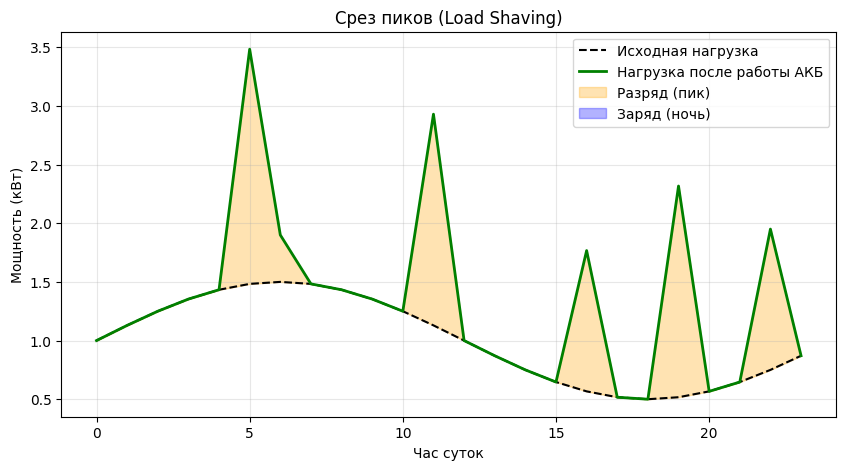

In [ ]:
import json

class LLMAgent:
    def __init__(self, client):
        self.client = client

    def predict(self, obs):
        prompt = f"""
        ...
        Твоя задача: управлять двумя батареями раздельно. 
        Стратегия: 
        1. Используй Батарею 1 (SOH {obs[1]:.2f}) как основную, так как она здоровее.
        2. Батарею 2 (SOH {obs[3]:.2f}) используй только при критических пиках нагрузки.
        3. Избегай одновременного включения обеих батарей — это неэффективно для сети.
        
        Прими решение: какое количество энергии направить в каждую батарею (от -1.0 до 1.0).
        Важно: приоритизируй батарею с лучшим SOH, если они обе здоровы — балансируй нагрузку.
        Верни ТОЛЬКО JSON в формате: {{"a1": 0.0, "a2": 0.0}}
        """

        # Запрос к Qwen
        response = ask_qwen(prompt)
        
        # Парсинг JSON из ответа
        try:
            # Ищем подстроку с JSON, если модель добавила лишний текст
            json_str = re.search(r'\{.*\}', response).group(0)
            data = json.loads(json_str)
            return [data['a1'], data['a2']]
        except:
            return [0.0, 0.0] # Безопасный возврат на случай ошибки

# Инициализация и запуск
llm_agent = LLMAgent(client)
battery_ids = ["CS2_35", "CS2_36"]
env = BatteryEnv(cell_ids=battery_ids)

# Запуск эпизода с LLM
history_llm = run_episode_detailed(env, llm_agent.predict)

# Визуализация
plot_load_shaving(env, history_llm)

In [31]:
class HierarchicalLLMSACController:
    def __init__(self, sac_model, openai_client):
        self.sac = sac_model
        self.client = openai_client

    def select_action(self, obs):
        # 1. Получаем базовое решение от SAC
        sac_action, _ = self.sac.predict(obs, deterministic=True)
        
        # 2. Очень короткий и жесткий промпт
        prompt = f"""
        B1_SOC: {obs[0]:.2f}, B1_SOH: {obs[1]:.2f}
        B2_SOC: {obs[2]:.2f}, B2_SOH: {obs[3]:.2f}
        Load: {obs[4]:.2f}, Price: {obs[6]:.2f}, Hour: {obs[7]:.0f}

        Task: Output ONLY valid JSON matching this format:
        {{"mask_b1": 1, "mask_b2": 0}}
        Do not write any prose, markdown block, or explanation. Just the JSON object.
        """

        # Просим Qwen отвечать МАКСИМАЛЬНО строго
        response = ask_qwen(prompt, system_role="You are a machine that outputs only raw JSON. Never write text explanations.")
        
        # Печатаем, чтобы своими глазами увидеть, что она там пишет
        print(f"Час {obs[7]:.0f} | Сырой ответ Qwen: {response.strip()}")
        
        try:
            # Очищаем ответ от возможных markdown-тегов ```json ... ```
            clean_response = response.replace("```json", "").replace("```", "").strip()
            # Пытаемся найти JSON по скобкам
            match = re.search(r'\{.*?\}', clean_response, re.DOTALL)
            
            if match:
                data = json.loads(match.group(0))
            else:
                # Если регулярка не нашла скобок, пробуем распарсить строку целиком
                data = json.loads(clean_response)
                
            mask_b1 = float(data['mask_b1'])
            mask_b2 = float(data['mask_b2'])
            
            print(f"   -> Маска успешно применена: [{mask_b1}, {mask_b2}]")
            return sac_action * np.array([mask_b1, mask_b2])
            
        except Exception as e:
            # Если опять сбой — теперь мы чередуем батареи вручную, 
            # чтобы график СТОПРОЦЕНТНО изменился, и мы увидели разницу
            print(f"   !!! Сбой парсинга: {e}. Применяем аварийное чередование.")
            if int(obs[7]) % 2 == 0:
                return sac_action * np.array([1.0, 0.0]) # В четные часы работает Бат 1
            else:
                return sac_action * np.array([0.0, 1.0]) # В нечетные часы работает Бат 2

Час 0 | Сырой ответ Qwen: {"mask_b1": 1, "mask_b2": 0}
   -> Маска успешно применена: [1.0, 0.0]
Час 1 | Сырой ответ Qwen: {"mask_b1": 1, "mask_b2": 0}
   -> Маска успешно применена: [1.0, 0.0]
Час 2 | Сырой ответ Qwen: ```json
{"mask_b1": 1, "mask_b2": 0}
```
   -> Маска успешно применена: [1.0, 0.0]
Час 3 | Сырой ответ Qwen: {"mask_b1": 1, "mask_b2": 0}
   -> Маска успешно применена: [1.0, 0.0]
Час 4 | Сырой ответ Qwen: {"mask_b1": 1, "mask_b2": 0}
   -> Маска успешно применена: [1.0, 0.0]
Час 5 | Сырой ответ Qwen: {"mask_b1": 1, "mask_b2": 0}
   -> Маска успешно применена: [1.0, 0.0]
Час 6 | Сырой ответ Qwen: {"mask_b1": 1, "mask_b2": 0}
   -> Маска успешно применена: [1.0, 0.0]
Час 7 | Сырой ответ Qwen: {"mask_b1": 1, "mask_b2": 0}
   -> Маска успешно применена: [1.0, 0.0]
Час 8 | Сырой ответ Qwen: {"mask_b1": 1, "mask_b2": 0}
   -> Маска успешно применена: [1.0, 0.0]
Час 9 | Сырой ответ Qwen: {"mask_b1": 1, "mask_b2": 0}
   -> Маска успешно применена: [1.0, 0.0]
Час 10 | Сырой отв

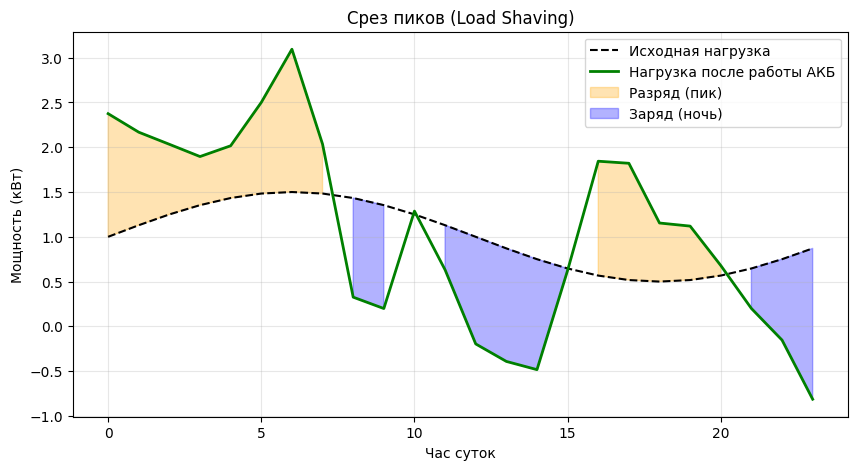

In [32]:
hybrid_agent = HierarchicalLLMSACController(sac_model=modelSAC, openai_client=client)

# Сбрасываем среду
battery_ids = ["CS2_35", "CS2_36"]
env = BatteryEnv(cell_ids=battery_ids)

# Модифицированная функция прогона эпизода (передаем метод select_action вместо model.predict)
history_hybrid = run_episode_detailed(env, hybrid_agent.select_action)

# Строим графики сглаживания нагрузки
plot_load_shaving(env, history_hybrid)